# TensorFlow overview
While the homeworks will be written in torch, the labs are written in tensorflow. Most of the time, only a very basic tensorflow knowledge suffices for solving them. Since tensorflow is not used during other ML courses at MIMUW, we will introduce it briefly here.

In [1]:
import tensorflow as tf
import numpy as np
import keras
from keras import layers
from keras import losses
import functools

2025-05-03 21:27:45.094628: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746300465.218518   49487 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746300465.260587   49487 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746300465.499177   49487 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746300465.499198   49487 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746300465.499200   49487 computation_placer.cc:177] computation placer alr

#Tensors

Example tensor operations in tensorflow




In [2]:
print(tf.math.add(1, 2))
print(tf.math.add([1, 2], [3, 4]))
print(tf.math.square(5))
print(tf.math.reduce_sum([1, 2, 3]))

# Operator overloading is also supported
print(tf.math.square(2) + tf.math.square(3))

tf.Tensor(3, shape=(), dtype=int32)
tf.Tensor([4 6], shape=(2,), dtype=int32)
tf.Tensor(25, shape=(), dtype=int32)
tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(13, shape=(), dtype=int32)


2025-05-03 21:27:51.035619: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In contrast to pytorch, in tensorflow numpy arrays can be used instead of tf.Tensor - they get converted automatically:

In [3]:
ndarray = np.ones([3, 3])

print("TensorFlow operations convert numpy arrays to Tensors automatically")
tensor = tf.math.multiply(ndarray, 42)
print(tensor)

print("And NumPy operations convert Tensors to NumPy arrays automatically")
print(np.add(tensor, 1))

TensorFlow operations convert numpy arrays to Tensors automatically
tf.Tensor(
[[42. 42. 42.]
 [42. 42. 42.]
 [42. 42. 42.]], shape=(3, 3), dtype=float64)
And NumPy operations convert Tensors to NumPy arrays automatically
[[43. 43. 43.]
 [43. 43. 43.]
 [43. 43. 43.]]


Tensorflow automatically decides which device to choose for execution - it moves tensors between GPU and CPU as needed. Of course it is also possible to do it manually.

In [4]:
x = tf.random.uniform([3, 3])

print("Is there a GPU available: "),
print(tf.config.list_physical_devices("GPU"))

print("Is the Tensor on GPU #0:  "),
print(x.device.endswith('GPU:0'))


Is there a GPU available: 
[]
Is the Tensor on GPU #0:  
False


In [5]:
###########################################
# Implement mse loss                      #
# using vector operations from tensorflow #
###########################################

def mse_loss(y_true, y_pred):
  ### TODO ###
  square_error = tf.math.square(tf.math.subtract(y_true, y_pred))
  result = tf.math.reduce_mean(square_error)

  return result
  ### END ###


loss_fn = tf.keras.losses.MeanSquaredError()
y_true = np.random.rand(4, 10)
y_pred = np.random.rand(4, 10)
print(loss_fn(y_true, y_pred))
print(mse_loss(y_true, y_pred.astype(np.float64)))



tf.Tensor(0.13585575, shape=(), dtype=float32)
tf.Tensor(0.13585575398591834, shape=(), dtype=float64)


## Dataset Definition
The dataset we will be using for network training is Cifar10.

In [6]:
dataset = tf.keras.datasets.cifar10

(x_train, y_train), (x_test, y_test) = dataset.load_data()

##############################################
# Scale the data to be in (0, 1) interval    #
##############################################
### TODO ###

def normalize(tensor):
  max_, min_ = tf.math.reduce_max(tensor), tf.math.reduce_min(tensor)
  return tf.math.divide(tensor - min_, max_ - min_)

def check_norm(t):
  print(tf.math.reduce_min(t), tf.math.reduce_max(t))

x_train = normalize(x_train)
x_test = normalize(x_test)

check_norm(x_train)
check_norm(x_test)

### END ###

tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)


In [7]:
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))

## Keras Sequential
The most straightforward wat to define a model is using Keras Sequential.

In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])

model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.1939 - loss: 2.1250
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2684 - loss: 1.9537
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3009 - loss: 1.9018
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3064 - loss: 1.8996
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3134 - loss: 1.8851
313/313 - 1s - 4ms/step - accuracy: 0.3416 - loss: 1.8277


We can use `keras.utils.plot_model` to plot the model.

In [ ]:
!echo $VIRTUAL_ENV
keras.utils.plot_model(model, "dense_model.png")

/home/nojak/Git/ML12/venv


NameError: name 'model' is not defined

We can call the model as in torch. The mode that the model is called in can be specified by passing the `training` argument.

In [ ]:
features = tf.random.normal((10, 32, 32, 3))
predictions = model(features, training=False)

print(predictions)

tf.Tensor(
[[-0.13493353  0.12741905 -0.16697925  0.04965559 -0.08058979 -0.2359967
  -0.12832238 -0.07594483  0.12119087  0.2575341 ]
 [-0.7538152  -0.12929992 -0.31287128  0.7767873  -0.36689696  0.71070457
   0.3189057  -0.22267449 -0.75496674 -0.9451693 ]
 [-0.78787565 -0.8563236   0.4646441   0.55537057  0.37959117  0.4482274
   0.8955661  -0.12142167 -1.658049   -1.624298  ]
 [-0.2523082  -0.13383712  0.01695237  0.00829864  0.17969199 -0.13093588
   0.06696105  0.0754468  -0.42849013 -0.11582962]
 [-0.47669908 -0.4180292   0.27751562  0.40221316  0.40047717  0.23589653
   0.6483108   0.13235316 -1.2393926  -0.8366927 ]
 [-0.17922531 -0.8495568   0.33777046 -0.06317088  0.48109233 -0.02068122
   0.1694028  -0.1972659  -0.8156973  -1.0508703 ]
 [-0.31966358  0.02108375 -0.09806857  0.22244954  0.10719957 -0.04292186
   0.26864153 -0.06199395 -0.2555321  -0.03882698]
 [ 0.24423352 -0.12679358  0.03408882 -0.15214194 -0.04589205 -0.5373644
  -0.45124876 -0.10392226  0.3457747   0.13

Then we can convert it to logits and find the predictions

In [ ]:
##########################################
#   Convert the predictions to logits    #
#   And calculate the resulting label    #
##########################################

### TODO ###
probs = tf.math.softmax(predictions, axis = 1)

logits = tf.math.log(probs)

samples = tf.random.categorical(logits, num_samples=1)

### END ###

Using your background from the dnn course and layers from `tf.keras.layers`  define the model so that the accuracy of 0.5 is reached within 5 epochs.

In [ ]:
##############################################
# Define a convolutional network             #
# That gets an accuracy over 50% in 5 epochs #
##############################################

### TODO ###

### END ###

model = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters = 32, kernel_size = 3, padding = 'same'),
  tf.keras.layers.ReLU(),
  tf.keras.layers.Conv2D(filters = 32, kernel_size = 3, padding = 'same'),
  tf.keras.layers.ReLU(),
  tf.keras.layers.MaxPool2D(strides = 2),

  tf.keras.layers.Conv2D(filters = 64, kernel_size = 3, padding = 'same'),
  tf.keras.layers.ReLU(),
  tf.keras.layers.Conv2D(filters = 64, kernel_size = 3, padding = 'same'),
  tf.keras.layers.ReLU(),
  tf.keras.layers.MaxPool2D(strides = 2),

  tf.keras.layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same'),
  tf.keras.layers.ReLU(),
  tf.keras.layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same'),
  tf.keras.layers.ReLU(),
  tf.keras.layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same'),
  tf.keras.layers.ReLU(),
  tf.keras.layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same'),
  tf.keras.layers.ReLU(),
  tf.keras.layers.MaxPool2D(strides = 2),

  tf.keras.layers.Flatten(input_shape=(4, 4, 128)),
  tf.keras.layers.Dense(512, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(512, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# print(model(x_train[:2]))
# print(x_train.shape)

model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.2675 - loss: 1.9326
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.5120 - loss: 1.3346
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6211 - loss: 1.0728
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6750 - loss: 0.9235
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7115 - loss: 0.8241
313/313 - 2s - 8ms/step - accuracy: 0.6876 - loss: 0.8969


## Keras Functional API
Keras functional API allows for creating more flexible models than `keras.Sequential`. It will therefore be useful during this course.

Let's build the same dense model as before.

In [ ]:
inputs = keras.Input(shape=(3072,))
dense = layers.Dense(64, activation="relu")
x = dense(inputs)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(10)(x)

model = keras.Model(inputs=inputs, outputs=outputs)

And again fit it to the data.

In [ ]:
##################################
# Flatten the images             #
##################################
### TODO ###

x_flat_train = layers.Flatten('channels_last')(x_train)
x_flat_test = layers.Flatten('channels_last')(x_test)

### DONE ###

loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)

##############################################
# Train the model with batch size 128        #
# And learning rate 0.001                    #
##############################################
### TODO ###

optimizer = keras.optimizers.Adam(learning_rate = 0.001)

model.compile(
  optimizer = optimizer,
  loss = loss_fn,
  metrics = ['accuracy'],
)

model.fit(x_flat_train, y_train, batch_size = 128, epochs = 5)

### DONE ###

test_loss, test_acc = model.evaluate(x_flat_test,  y_test, verbose=2)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1669 - loss: 2.1836
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2382 - loss: 2.0036
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2489 - loss: 1.9728
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2611 - loss: 1.9510
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2687 - loss: 1.9337
313/313 - 1s - 2ms/step - accuracy: 0.3191 - loss: 1.8527


Define the same network as in the previous exercise, but using the functional approach.

Write a training loop that does the same thing as happens above manually.

Create network with a plot like this on right.

In [ ]:
class CustomDenseLayer(tf.keras.layers.Layer):
  def __init__(self, units=32, activation=None):
    super(CustomDenseLayer, self).__init__()
    self.units = units
    self.activation = tf.keras.activations.get(activation)

  def build(self, input_shape):
    # Create weights and biases
    self.w = self.add_weight(
      shape=(input_shape[-1], self.units),
      initializer="glorot_uniform",
      trainable=True,
        name="kernel"
    )
    self.b = self.add_weight(
      shape=(self.units,),
      initializer="zeros",
      trainable=True,
      name="bias"
    )

  def call(self, inputs):
      return self.activation(tf.matmul(inputs, self.w) + self.b)


In [28]:
class PrintLayer(tf.keras.layers.Layer):
  def __init__(self):
    super(PrintLayer, self).__init__()

  def build(self):
    pass

  def call(self, inputs):
    print(inputs)
    return inputs

In [ ]:
######################################
# Define the same convnet as before, #
# But use the functional API         #
######################################

### TODO ###

inputs = keras.Input(shape=(32, 32, 3))
x = layers.Identity()(inputs)

filters = 32
for times in [2, 2, 4]:
  for i in range(times):
    x = layers.Conv2D(filters = filters, kernel_size = 3, padding = 'same')(x)
    x = layers.ReLU()(x)

    if i == 0:
      x_residual = x
    elif i == times - 1:
      x += x_residual

  x = layers.MaxPool2D(strides = 2)(x)
  filters *= 2

# x = PrintLayer()(x)

shape = (4, 4, 128)
flattened = functools.reduce(lambda x, y: x * y, list(shape))
print(flattened)

x = layers.Flatten(input_shape = shape)(x)

for _ in range(2):
  x = layers.Dense(flattened, activation="relu")(x)
  x = layers.Dropout(0.1)(x)

outputs = layers.Dense(10)(x)

### END ###

model = keras.Model(inputs=inputs, outputs=outputs)

2048


/home/nojak/Git/ML12/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

# keras.utils.plot_model(model, "dense_model.png")

In [ ]:
model.fit(x_train, y_train, batch_size = 128, epochs=5)
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.3377 - loss: 1.7903
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.6180 - loss: 1.0665
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7118 - loss: 0.8149
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7698 - loss: 0.6578
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8187 - loss: 0.5194
313/313 - 3s - 9ms/step - accuracy: 0.7552 - loss: 0.7285


In [12]:
######################################
# Add a residual connection to your #
# convnet, use the functional API   #
######################################

inputs = keras.Input(shape=(32, 32, 3))
x = layers.Identity()(inputs)

filters = 32
for times in [2, 2, 4]:
  for i in range(times):
    x = layers.Conv2D(filters = filters, kernel_size = 3, padding = 'same')(x)
    x = layers.ReLU()(x)

    if i == 0:
      x_residual = x
    elif i == times - 1:
      x += x_residual

  x = layers.MaxPool2D(strides = 2)(x)
  filters *= 2

shape = (4, 4, 128)
flattened = functools.reduce(lambda x, y: x * y, list(shape))

x = layers.Flatten(input_shape = shape)(x)

for _ in range(2):
  x = layers.Dense(flattened, activation="relu")(x)
  x = layers.Dropout(0.1)(x)

outputs = layers.Dense(10)(x)

model = keras.Model(inputs=inputs, outputs=outputs)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sometimes just using `.fit` method might not be enough. It is also possible to write the training loop more from scratch.

In [ ]:
batch_size = 32

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
ds_train_batch = train_dataset.batch(batch_size)
ds_test_batch = test_dataset.batch(batch_size)

def simple_forward(x, model, training):
  ########################################
  #   Get the predictions from the model #
  ########################################

  ### TODO ###

  return model(x, training = training)

  ### END ###

def loss(model, x, y, training, forward_fn):
  # training=training is needed only if there are layers with different
  # behavior during training versus inference (e.g. Dropout).
  y_ = forward_fn(x, model, training)
  return loss_fn(y_true=y, y_pred=y_)

@tf.function
def grad(model, inputs, targets, forward_fn):
  with tf.GradientTape() as tape:
    loss_value = loss(model, inputs, targets, training=True, forward_fn=forward_fn)

  return loss_value, tape.gradient(loss_value, model.trainable_variables)

@tf.function
def run_training(optimizer, num_epoch, model, forward_fn):

  for epoch in range(num_epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()
    epoch_accuracy = tf.keras.metrics.SparseCategoricalAccuracy()

    test_epoch_loss_avg = tf.keras.metrics.Mean()
    test_epoch_accuracy = tf.keras.metrics.SparseCategoricalAccuracy()

    for step, (x, y) in enumerate(ds_train_batch):
      loss_value, grads = grad(model, x, y, forward_fn)

      ########################
      # Apply the gradients  #
      ########################

      ### TODO ###

      optimizer.apply_gradients(zip(grads, model.trainable_variables))

      # Not a correct approach xd
      # for layer in model.layers:
      #   for w in layer.weights:
      #     grad_matrix = grads.pop(0)
      #     assert grad_matrix.shape == w.shape
      #     w.assign_add(grad_matrix)

      ### END ###

      epoch_loss_avg.update_state(loss_value)
      epoch_accuracy.update_state(y, model(x, training=True))

      if (step + 1) % 10 == 0:
        print(
          f"\r{step+1}/{len(ds_train_batch)} - "
          f"loss: {epoch_loss_avg.result():.4f} - "
          f"accuracy: {epoch_accuracy.result():.4f}",
          end=""
        )

    print(
      "Epoch {:03d}: Loss: {:.3f}, Accuracy: {:.3%}".format(
        epoch,
        epoch_loss_avg.result(),
        epoch_accuracy.result(),
      )
    )

    ######################
    # Run the test epoch #
    ######################
    ### TODO ###
    for step, (x, y) in enumerate(ds_test_batch):
      loss_value, grads = grad(model, x, y, forward_fn)
      epoch_accuracy.update_state(y, model(x, training=True))

      if (step + 1) % 10 == 0:
        print(
          f"\r{step+1}/{len(ds_train_batch)} - "
          f"accuracy: {epoch_accuracy.result():.4f}",
          end=""
        )

    print(
      "Accuracy: {:.3%}".format(
        epoch_accuracy.result(),
      )
    )

    ### END ###

optimizer = tf.keras.optimizers.Adam()
num_epochs = 5

run_training(optimizer, num_epochs, model, simple_forward)


KeyboardInterrupt: 

Humans have two eyes. Let's try to simulate something similar with a neural network, that is train a separate encoder for the left and right parts of the image and then encode them together. Your network should have a plot similar to this one: 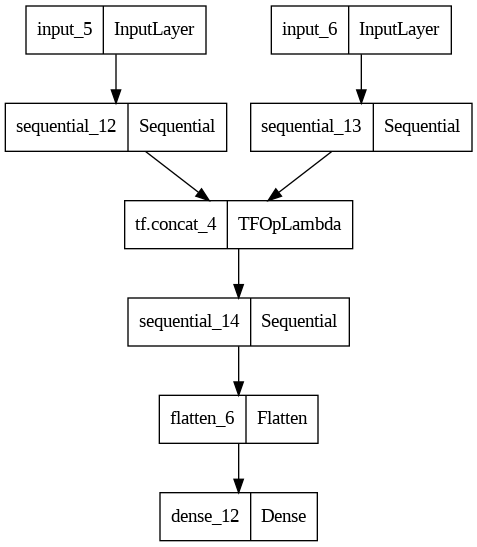

In [72]:
#######################################
# Split x_train and x_test into       #
# two inputs with shapes (32, 16, 3)  #
#######################################

### TODO ###
def lr_divide(x, div_point):
  div_point_r = x.shape[2] - div_point

  return (
    x[:,:,:div_point,:],
    x[:,:,div_point_r:,:],
  )

x_train_l, x_train_r = lr_divide(x_train, 20)
x_test_l, x_test_r = lr_divide(x_test, 20)

### END ###

In [73]:
num_epochs = 5

def get_block(input_shape):
  model = tf.keras.models.Sequential([
    layers.Input(shape = input_shape),
    layers.Conv2D(3, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(3, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(3, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
  ])

  return model



def build_model(x, batch_size):
  #######################################
  # Build the model so that its plot    #
  # resembles the one from the image    #
  #######################################

  ### TODO ###

  xl_in = keras.Input(shape = x.shape[1:])
  xr_in = keras.Input(shape = x.shape[1:])

  block_shape = (batch_size, *xl_in.shape[1:])
  xl = get_block(block_shape[1:])(xl_in)
  xr = get_block(block_shape[1:])(xr_in)

  x = layers.Concatenate(axis = 2)([xl, xr])

  block_shape = (batch_size, *x.shape[1:])
  x = get_block(block_shape[1:])(x)

  x = layers.Flatten(input_shape = x.shape)(x)
  x = layers.Dense(x.shape[1])(x)
  x = layers.Dense(10)(x)

  return keras.Model(inputs = [xl_in, xr_in], outputs = x)

  ### END ###


In [76]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

print(x_test_l.shape[1:])
model = build_model(x_test_l, 128)

keras.utils.plot_model(model, "two_inputs_model.png")

model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

###################
# Fit the model   #
###################
### TODO ###

model.fit(
  x = [x_train_l, x_train_r],
  y = y_train,
  batch_size = 128,
  epochs = 5,
)

### END ###

#######################
# Evaluate the model  #
#######################
### TODO ###

test_loss, test_acc = model.evaluate([x_test_l, x_test_r],  y_test, verbose=2)

### END ###

(32, 20, 3)


/home/nojak/Git/ML12/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
 50/391 ━━━━━━━━━━━━━━━━━━━━ 1:45 308ms/step - accuracy: 0.2208 - loss: 9.1429

KeyboardInterrupt: 